# Obligatorio - Taller de Tecnologías 2

## 1. Setup

Install dependencies, import libraries and load API keys from Colab Secrets.

### 1.1 Install dependencies

In [1]:
%pip install -U \
  langchain==0.3.7 \
  langchain-core==0.3.18 \
  langchain-openai==0.2.3 \
  langchain-community==0.3.7 \
  langchain-pinecone==0.2.0 \
  langchain-huggingface==0.1.2 \
  langgraph==0.2.19 \
  sentence-transformers \
  pinecone-client \
  pydantic==2.9.2 \
  pypdf wikipedia requests

  Using cached pinecone_client-6.0.0-py3-none-any.whl.metadata (3.4 kB)


### 1.2 Imports

In [2]:
import os
import re
import ast
import time
from pathlib import Path
import uuid

import pandas as pd
import numpy as np
from tqdm.auto import tqdm

from sentence_transformers import SentenceTransformer
from pinecone import Pinecone, ServerlessSpec

from google.colab import userdata, drive

### 1.3 Load API keys from Colab Secrets

In [3]:
os.environ["OPENAI_API_KEY"] = userdata.get("OPENAI_API_KEY")
os.environ["PINECONE_API_KEY"] = userdata.get("PINECONE_API_KEY")
os.environ["HF_TOKEN"] = userdata.get("HF_TOKEN")

print("Secrets loaded.")

Secrets loaded.


### 1.4 Mount Google Drive

In [4]:
drive.mount("/content/drive")

DRIVE_ROOT = Path("/content/drive/MyDrive/Obligatorio-TT2/dataset")
RECIPES_CSV = DRIVE_ROOT / "food.com" / "RAW_recipes.csv"
PAPERS_DIR = DRIVE_ROOT / "papers"

assert RECIPES_CSV.exists(), f"Recipes CSV not found at {RECIPES_CSV}"
assert PAPERS_DIR.exists(), f"Papers folder not found at {PAPERS_DIR}"
print("Drive mounted and paths verified.")

Mounted at /content/drive
Drive mounted and paths verified.


### 1.5 Initialize embedding model and Pinecone client


In [5]:
# Embedding model
EMBED_MODEL_NAME = "sentence-transformers/all-MiniLM-L6-v2"
EMBED_DIM = 384

embed_model = SentenceTransformer(EMBED_MODEL_NAME, device="cuda")
print(f"Loaded embedding model on {embed_model.device}")

# Pinecone client
pc = Pinecone(api_key=os.environ["PINECONE_API_KEY"])
print("Pinecone client initialized.")

modules.json:   0%|          | 0.00/349 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/116 [00:00<?, ?B/s]

README.md:   0%|          | 0.00/10.5k [00:00<?, ?B/s]

sentence_bert_config.json:   0%|          | 0.00/53.0 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/612 [00:00<?, ?B/s]

...

vocab.txt:   0%|          | 0.00/232k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/466k [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/190 [00:00<?, ?B/s]

Loaded embedding model on cuda:0
Pinecone client initialized.


## 2. Dataset ingestion (recipes)

Load Food.com recipes CSV → clean → sample → embed → upload to Pinecone in namespace recipes.

### 2.1 Load raw CSV

In [6]:
raw_df = pd.read_csv(RECIPES_CSV)
print(f"Loaded {len(raw_df):,} recipes with columns: {list(raw_df.columns)}")
raw_df.head(3)

Loaded 231,637 recipes with columns: ['name', 'id', 'minutes', 'contributor_id', 'submitted', 'tags', 'nutrition', 'n_steps', 'steps', 'description', 'ingredients', 'n_ingredients']


,name,id,minutes,contributor_id,submitted,tags,nutrition,n_steps,steps,description,ingredients,n_ingredients
0,arriba baked winter squash mexican style,137739,55,47892,2005-09-16,"['60-minutes-or-less', 'time-to-make', 'course...","[51.5, 0.0, 13.0, 0.0, 2.0, 0.0, 4.0]",11,"['make a choice and proceed with recipe', 'dep...",autumn is my favorite time of year to cook! th...,"['winter squash', 'mexican seasoning', 'mixed ...",7
1,a bit different breakfast pizza,31490,30,26278,2002-06-17,"['30-minutes-or-less', 'time-to-make', 'course...","[173.4, 18.0, 0.0, 17.0, 22.0, 35.0, 1.0]",9,"['preheat oven to 425 degrees f', 'press dough...",this recipe calls for the crust to be prebaked...,"['prepared pizza crust', 'sausage patty', 'egg...",6
2,all in the kitchen chili,112140,130,196586,2005-02-25,"['time-to-make', 'course', 'preparation', 'mai...","[269.8, 22.0, 32.0, 48.0, 39.0, 27.0, 5.0]",6,"['brown ground beef in large pot', 'add choppe...",this modified version of 'mom's' chili was a h...,"['ground beef', 'yellow onions', 'diced tomato...",13


### 2.2 Clean and parse columns

In [7]:
def safe_literal_eval(value):
    """Parse a stringified list, return [] on failure."""
    try:
        return ast.literal_eval(value) if isinstance(value, str) else []
    except (ValueError, SyntaxError):
        return []

def clean_recipes(df: pd.DataFrame) -> pd.DataFrame:
    """Drop rows with empty essentials and parse list-like string columns."""
    df = df.copy()

    # Drop rows missing the fields we will actually use
    df = df.dropna(subset=["name", "ingredients", "steps"])

    # Fill missing description so concatenation does not blow up
    df["description"] = df["description"].fillna("")

    # Parse list-like columns from stringified lists into real Python lists
    for col in ["tags", "ingredients", "steps", "nutrition"]:
        df[col] = df[col].apply(safe_literal_eval)

    # Drop recipes with no ingredients or no steps after parsing
    df = df[df["ingredients"].map(len) > 0]
    df = df[df["steps"].map(len) > 0]

    return df.reset_index(drop=True)

clean_df = clean_recipes(raw_df)
print(f"After cleaning: {len(clean_df):,} recipes")
clean_df.head(3)

After cleaning: 231,635 recipes


,name,id,minutes,contributor_id,submitted,tags,nutrition,n_steps,steps,description,ingredients,n_ingredients
0,arriba baked winter squash mexican style,137739,55,47892,2005-09-16,"[60-minutes-or-less, time-to-make, course, mai...","[51.5, 0.0, 13.0, 0.0, 2.0, 0.0, 4.0]",11,"[make a choice and proceed with recipe, depend...",autumn is my favorite time of year to cook! th...,"[winter squash, mexican seasoning, mixed spice...",7
1,a bit different breakfast pizza,31490,30,26278,2002-06-17,"[30-minutes-or-less, time-to-make, course, mai...","[173.4, 18.0, 0.0, 17.0, 22.0, 35.0, 1.0]",9,"[preheat oven to 425 degrees f, press dough in...",this recipe calls for the crust to be prebaked...,"[prepared pizza crust, sausage patty, eggs, mi...",6
2,all in the kitchen chili,112140,130,196586,2005-02-25,"[time-to-make, course, preparation, main-dish,...","[269.8, 22.0, 32.0, 48.0, 39.0, 27.0, 5.0]",6,"[brown ground beef in large pot, add chopped o...",this modified version of 'mom's' chili was a h...,"[ground beef, yellow onions, diced tomatoes, t...",13


## 2.3 Sample to a manageable size

In [8]:
SAMPLE_SIZE = 30_000
SEED = 42

sampled_df = clean_df.sample(n=SAMPLE_SIZE, random_state=SEED).reset_index(drop=True)
print(f"Sampled {len(sampled_df):,} recipes")

Sampled 30,000 recipes


## 2.4 Build the text that will be embedded

We only embedded the free-text fields (name, description, ingredients) because that's where the semantic meaning users are searching for lives (e.g. "egg-free dessert"). Numeric values and categorical fields (minutes, tags, nutrition) are stored as metadata because they are better suited for exact filtering (minutes < 30) rather than cosine similarity.

In [9]:
def build_embed_text(row: pd.Series) -> str:
    """Concatenate name + description + ingredients into a single string for embedding."""
    ingredients = ", ".join(row["ingredients"])
    return (
        f"{row['name']}. "
        f"{row['description']} "
        f"Ingredients: {ingredients}."
    )

sampled_df["embed_text"] = sampled_df.apply(build_embed_text, axis=1)
print(sampled_df["embed_text"].iloc[0])

cottage cheese walnut dip. this was originally from another recipe , but i made so many variations that i decided it was mine! 
now instead of a pasta sauce this is a lovely fresh and easy dip. all ingredients should be room temperature , but chill just for a bit then stir before serving. Ingredients: cottage cheese, walnuts, black pepper, garlic cloves, fresh basil, margarine, fresh parsley, plain yogurt, parmesan cheese.


## 2.5 Build metadata for each recipe

The nutrition field is assumed to follow the dataset's documented schema: [calories, total_fat_pdv, sugar_pdv, sodium_pdv, protein_pdv, sat_fat_pdv, carbs_pdv]. Calories are stored in kcal, while all other values represent Percent Daily Value (PDV) rather than grams. A validation step confirms that nutrition lists contain 7 elements and that value ranges are reasonable before ingestion.

In [10]:
NUTRITION_KEYS = ["calories", "total_fat", "sugar", "sodium", "protein", "sat_fat", "carbs"]

def build_metadata(row: pd.Series) -> dict:
    """Return a Pinecone-friendly metadata dict for one recipe."""
    nutrition = dict(zip(NUTRITION_KEYS, row["nutrition"])) if len(row["nutrition"]) == 7 else {}
    return {
        "name": row["name"],
        "minutes": int(row["minutes"]) if pd.notna(row["minutes"]) else -1,
        "n_ingredients": int(row["n_ingredients"]) if pd.notna(row["n_ingredients"]) else -1,
        "n_steps": int(row["n_steps"]) if pd.notna(row["n_steps"]) else -1,
        "tags": row["tags"][:20],
        "ingredients": row["ingredients"][:30],
        **nutrition,
    }

sampled_df["metadata"] = sampled_df.apply(build_metadata, axis=1)
sampled_df["metadata"].iloc[0]

{'name': 'cottage cheese walnut dip',
 'minutes': 10,
 'n_ingredients': 9,
 'n_steps': 6,
 'tags': ['15-minutes-or-less',
  'time-to-make',
  'course',
  'main-ingredient',
  'preparation',
  'for-1-or-2',
  'appetizers',
  'eggs-dairy',
  'easy',
  'beginner-cook',
  'vegetarian',
  'dips',
  'cheese',
  'dietary',
  'gluten-free',
  'low-carb',
  'egg-free',
  'free-of-something',
  'low-in-something',
  'number-of-servings'],
 'ingredients': ['cottage cheese',
  'walnuts',
  'black pepper',
  'garlic cloves',
  'fresh basil',
  'margarine',
  'fresh parsley',
  'plain yogurt',
  'parmesan cheese'],
 'calories': 518.2,
 'total_fat': 67.0,
 'sugar': 20.0,
 'sodium': 23.0,
 'protein': 46.0,
 'sat_fat': 45.0,
 'carbs': 4.0}

## 2.6 Encode all recipes into embeddings

In [11]:
BATCH_SIZE = 128

texts = sampled_df["embed_text"].tolist()
embeddings = embed_model.encode(
    texts,
    batch_size=BATCH_SIZE,
    show_progress_bar=True,
    convert_to_numpy=True,
    normalize_embeddings=True,
)
print(f"Embeddings shape: {embeddings.shape}")

Batches:   0%|          | 0/235 [00:00<?, ?it/s]

Embeddings shape: (30000, 384)


## 2.7 Create the Pinecone index

In [12]:
INDEX_NAME = "tt2-obligatorio"
RECIPES_NS = "recipes"
PAPERS_NS = "papers"
MEMORY_NS_PREFIX = "memory"  # one namespace per user_id

existing = [idx.name for idx in pc.list_indexes()]
if INDEX_NAME not in existing:
    pc.create_index(
        name=INDEX_NAME,
        dimension=EMBED_DIM,
        metric="cosine",
        spec=ServerlessSpec(cloud="aws", region="us-east-1"),
    )
    print(f"Created index '{INDEX_NAME}'.")
else:
    print(f"Index '{INDEX_NAME}' already exists, reusing.")

index = pc.Index(INDEX_NAME)

Index 'tt2-obligatorio' already exists, reusing.


## 2.7.1 Reset namespaces (optional)

Wipe every namespace of the index so ingestion starts from a clean state. Set `RESET_INDEX = True` to clear recipes, papers and all per-user memory before re-uploading. Leave it `False` to keep existing data.

In [13]:
# Optional clean slate: delete all vectors from every namespace before ingesting.
# This clears recipes, papers and all memory_<user> namespaces in one go.
RESET_INDEX = True

if RESET_INDEX:
    stats = index.describe_index_stats()
    namespaces = list(stats.get("namespaces", {}).keys())
    if namespaces:
        for ns in namespaces:
            index.delete(delete_all=True, namespace=ns)
            print(f"Cleared namespace '{ns}'")
        time.sleep(2)
    else:
        print("Index is already empty, nothing to clear.")
    print(index.describe_index_stats())
else:
    print("RESET_INDEX is False, keeping existing data.")


Cleared namespace 'memory_eval_alice'
Cleared namespace 'recipes'
Cleared namespace 'memory_sofia'
Cleared namespace 'memory_alice'
Cleared namespace 'memory_nicolas'
Cleared namespace 'papers'
{'dimension': 384,
 'index_fullness': 0.0,
 'namespaces': {},
 'total_vector_count': 0}


## 2.8 Upsert recipe vectors into Pinecone

In [14]:
UPSERT_BATCH = 100

def upsert_recipes(df: pd.DataFrame, vectors: np.ndarray, namespace: str) -> None:
    """Upload (id, vector, metadata) triples to Pinecone in batches."""
    payload = []
    for i, (_, row) in enumerate(df.iterrows()):
        payload.append({
            "id": f"recipe-{row['id']}",
            "values": vectors[i].tolist(),
            "metadata": row["metadata"],
        })
        if len(payload) == UPSERT_BATCH:
            index.upsert(vectors=payload, namespace=namespace)
            payload = []
    if payload:
        index.upsert(vectors=payload, namespace=namespace)

upsert_recipes(sampled_df, embeddings, namespace=RECIPES_NS)

time.sleep(2)
print(index.describe_index_stats())

{'dimension': 384,
 'index_fullness': 0.0,
 'namespaces': {'recipes': {'vector_count': 30000}},
 'total_vector_count': 30000}


## 2.9 Test — semantic search on recipes

In [15]:
def test_search_recipes(query: str, top_k: int = 5) -> list[dict]:
    """Quick ingestion sanity check before the LangChain tools are defined."""
    q_vec = embed_model.encode(query, normalize_embeddings=True).tolist()
    res = index.query(
        vector=q_vec,
        top_k=top_k,
        namespace=RECIPES_NS,
        include_metadata=True,
    )
    return [
        {
            "score": round(match.score, 3),
            "name": match.metadata["name"],
            "minutes": match.metadata.get("minutes"),
        }
        for match in res.matches
    ]

test_search_recipes("quick vegetarian dinner with tomato and pasta")

[{'score': 0.69, 'name': 'mediterranean   basil pasta', 'minutes': 35.0},
 {'score': 0.688,
  'name': 'awesome and easy spaghetti casserole',
  'minutes': 60.0},
 {'score': 0.686, 'name': 'tomato and mushroom pasta', 'minutes': 25.0},
 {'score': 0.671,
  'name': 'beef  and pasta with mushroom sauce and vegetables',
  'minutes': 40.0},
 {'score': 0.67, 'name': 'tomato pasta with olives', 'minutes': 30.0}]

# 3. Papers ingestion

Load 6 PDFs → chunk → embed → upload to Pinecone in namespace papers.

## 3.1 Load PDFs with PyMuPDF

In [16]:
!pip install pymupdf

import fitz

def load_pdf_pages(pdf_path: Path) -> list[dict]:
    """Open one PDF and return a list of {paper, page, text} dicts, one per page."""
    paper_name = pdf_path.stem
    pages = []
    with fitz.open(pdf_path) as doc:
        for page_num, page in enumerate(doc, start=1):
            text = page.get_text("text").strip()
            if text:
                pages.append({"paper": paper_name, "page": page_num, "text": text})
    return pages

# Iterate all 6 PDFs in the papers folder
all_pages = []
for pdf_path in sorted(PAPERS_DIR.glob("*.pdf")):
    pages = load_pdf_pages(pdf_path)
    all_pages.extend(pages)
    print(f"{pdf_path.name}: {len(pages)} pages")

print(f"\nTotal pages across all papers: {len(all_pages)}")

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 25.0/25.0 MB 74.3 MB/s eta 0:00:00
2507.14805v1.pdf: 34 pages
Attention is all you need.pdf: 15 pages
Designing Data-Intensive Applications The Big Ideas Behind Reliable, Scalable, and Maintainable Systems by Martin Kleppmann (z-l.pdf: 591 pages
GPT Improving Language Understanding by Generative Pretraining.pdf: 12 pages
Language Models are Few-Shot Learners (GPT3).pdf: 75 pages
Scaling Laws for Neural Language Models.pdf: 30 pages

Total pages across all papers: 757


## 3.2 Chunk pages into ~500-token segments with overlap

In [17]:
from langchain_text_splitters import RecursiveCharacterTextSplitter

splitter = RecursiveCharacterTextSplitter(
    chunk_size=1000,
    chunk_overlap=200,
    separators=["\n\n", "\n", ". ", " ", ""],
)

def chunk_pages(pages: list[dict]) -> list[dict]:
    """Split each page's text into overlapping chunks, preserving paper/page metadata."""
    chunks = []
    for p in pages:
        for idx, chunk_text in enumerate(splitter.split_text(p["text"])):
            chunks.append({
                "paper": p["paper"],
                "page": p["page"],
                "chunk_idx": idx,
                "text": chunk_text,
            })
    return chunks

all_chunks = chunk_pages(all_pages)
print(f"Total chunks: {len(all_chunks)}")
print(f"\nExample chunk:\n{all_chunks[0]['text'][:300]}...")

Total chunks: 2649

Example chunk:
SUBLIMINAL LEARNING: LANGUAGE MODELS
TRANSMIT BEHAVIORAL TRAITS VIA HIDDEN SIGNALS
IN DATA
Alex Cloud∗1, Minh Le∗1
James Chua2, Jan Betley2, Anna Sztyber-Betley3, Jacob Hilton4
Samuel Marks5, Owain Evans2,6
∗Equal contribution; author order was chosen randomly.
1Anthropic Fellows Program, 2Truthful ...


## 3.3 Embed chunks and upsert to Pinecone (namespace papers)

In [18]:
chunk_texts = [c["text"] for c in all_chunks]
chunk_embeddings = embed_model.encode(
    chunk_texts,
    batch_size=BATCH_SIZE,
    show_progress_bar=True,
    convert_to_numpy=True,
    normalize_embeddings=True,
)
print(f"Chunk embeddings shape: {chunk_embeddings.shape}")

def upsert_papers(chunks: list[dict], vectors: np.ndarray, namespace: str) -> None:
    """Upload paper chunks to Pinecone in batches, with paper/page/text metadata."""
    payload = []
    for i, c in enumerate(chunks):
        payload.append({
            "id": f"{c['paper']}-p{c['page']}-c{c['chunk_idx']}",
            "values": vectors[i].tolist(),
            "metadata": {
                "paper": c["paper"],
                "page": c["page"],
                "chunk_idx": c["chunk_idx"],
                "text": c["text"][:1000],
            },
        })
        if len(payload) == UPSERT_BATCH:
            index.upsert(vectors=payload, namespace=namespace)
            payload = []
    if payload:
        index.upsert(vectors=payload, namespace=namespace)

upsert_papers(all_chunks, chunk_embeddings, namespace=PAPERS_NS)

time.sleep(2)
print(index.describe_index_stats())

Batches:   0%|          | 0/21 [00:00<?, ?it/s]

Chunk embeddings shape: (2649, 384)
{'dimension': 384,
 'index_fullness': 0.0,
 'namespaces': {'papers': {'vector_count': 2649},
                'recipes': {'vector_count': 30000}},
 'total_vector_count': 32649}


## 3.4 Test — semantic search on papers

In [19]:
def test_search_papers(query: str, top_k: int = 5) -> list[dict]:
    """Quick ingestion sanity check before the LangChain tools are defined."""
    q_vec = embed_model.encode(query, normalize_embeddings=True).tolist()
    res = index.query(
        vector=q_vec,
        top_k=top_k,
        namespace=PAPERS_NS,
        include_metadata=True,
    )
    return [
        {
            "score": round(match.score, 3),
            "paper": match.metadata["paper"],
            "page": match.metadata["page"],
            "snippet": match.metadata["text"][:200] + "...",
        }
        for match in res.matches
    ]

for q in [
    "what is multi-head attention",
    "scaling laws for language models",
    "few-shot in-context learning",
]:
    print(f"\nQuery: {q}")
    for hit in test_search_papers(q, top_k=3):
        print(f"[{hit['score']}] {hit['paper']} p{hit['page']}")
        print(hit["snippet"])


Query: what is multi-head attention
[0.594] Attention is all you need p5.0
output values. These are concatenated and once again projected, resulting in the final values, as
depicted in Figure 2.
Multi-head attention allows the model to jointly attend to information from diff...
[0.585] Attention is all you need p3.0
3.2
Attention
An attention function can be described as mapping a query and a set of key-value pairs to an output,
where the query, keys, values, and output are all vectors. The output is computed as ...
[0.492] Attention is all you need p5.0
Applications of Attention in our Model
The Transformer uses multi-head attention in three different ways:
• In "encoder-decoder attention" layers, the queries come from the previous decoder layer,
and...

Query: scaling laws for language models
[0.736] Scaling Laws for Neural Language Models p16.0
N(Cmin) ∝(Cmin)αmin
C
/αN ≈(Cmin)0.71
(6.5)
which also matches the scaling of Figure 14 to within a few percent. Our scaling laws provide a

## 4. Tools


In [20]:
from contextvars import ContextVar
from langchain_core.tools import tool

# DataFrame used by filter_recipes — points to the sample from section 2.3
RECIPES_DF = sampled_df

# Current user_id for memory tools — overwritten by the session wrapper before each invoke
current_user_id: ContextVar[str] = ContextVar("current_user_id", default="default_user")


def canonical_memory_text(text: str) -> str:
    """Normalize memory text so tiny wording changes do not create duplicates."""
    canonical = " ".join(str(text).lower().strip().split())
    canonical = re.sub(r"[^\w\sáéíóúñü-]", "", canonical)
    canonical = re.sub(r"^(the\s+)?user\s+", "", canonical)
    canonical = re.sub(r"^(is|am)\s+", "", canonical)
    canonical = re.sub(r"\b(enjoys|likes|loves)\b", "likes", canonical)
    return canonical.strip()

### 4.1 Tool: search_recipes (semantic)

In [21]:
@tool
def search_recipes(query: str, top_k: int = 5) -> str:
    """Semantic search over the recipe knowledge base.

    Use this when the user asks for recipe ideas or dish suggestions that
    benefit from matching descriptions and ingredients (e.g. "a quick vegan
    dessert with chocolate").

    Do NOT use this for hard constraints like exact cooking time, calorie
    limits or required tags — use filter_recipes for those. Combine both
    tools when the query has a semantic component AND a hard constraint.

    Returns up to top_k recipes with name, time
    and a few key ingredients.
    """
    q_vec = embed_model.encode(query, normalize_embeddings=True).tolist()
    res = index.query(vector=q_vec, top_k=top_k, namespace=RECIPES_NS, include_metadata=True)
    if not res.matches:
        return "No recipes found."
    lines = []
    for m in res.matches:
        md = m.metadata
        ings = ", ".join(md.get("ingredients", [])[:8])
        lines.append(f"- {md['name']} ({md.get('minutes', '?')} min) — ingredients: {ings}")
    return "\n".join(lines)

### 4.1 Tool: filter_recipes (structured)

In [22]:
@tool
def filter_recipes(
    max_minutes: int | None = None,
    must_have_tag: str | None = None,
    must_have_ingredient: str | None = None,
    max_calories: float | None = None,
    limit: int = 10,
) -> str:
    """Structured filter over recipes using exact or numeric constraints.

    Use this when the user has hard requirements: max cooking time, a
    required tag (e.g. "vegan", "dessert"), an ingredient that must appear,
    or a calorie ceiling.

    Do NOT use this for vague or stylistic queries — use search_recipes
    instead. Combine both tools when the query has both a semantic component
    and a hard constraint (e.g. "a spicy vegan dish under 30 minutes")

    All parameters are optional — only pass the ones the user explicitly
    mentioned.
    """
    df = RECIPES_DF
    mask = pd.Series([True] * len(df), index=df.index)
    if max_minutes is not None:
        mask &= df["minutes"] <= max_minutes
    if must_have_tag is not None:
        t = must_have_tag.lower()
        mask &= df["tags"].apply(lambda ts: t in [x.lower() for x in ts])
    if must_have_ingredient is not None:
        ing = must_have_ingredient.lower()
        mask &= df["ingredients"].apply(lambda xs: any(ing in x.lower() for x in xs))
    if max_calories is not None:
        mask &= df["nutrition"].apply(lambda xs: len(xs) == 7 and xs[0] <= max_calories)
    matches = df[mask].head(limit)
    if matches.empty:
        return "No recipes match those filters."
    return "\n".join(
        f"- {row['name']} ({row['minutes']} min, {row['n_ingredients']} ingredients)"
        for _, row in matches.iterrows()
    )

### 4.3 Tool: search_papers (semantic)

In [23]:
@tool
def search_papers(query: str, top_k: int = 6) -> str:
    """Semantic search over the AI papers knowledge base.

    Use this for questions about AI / ML / LLM topics covered in the
    course papers: Transformers, attention, GPT, scaling laws, few-shot
    learning, subliminal learning, data-intensive systems.

    Do NOT use this for recipe questions or personal user context.

    Returns an explicit source label (paper, page, chunk) plus a short
    snippet for each match, so the answer can cite exactly what was retrieved.
    """
    q_vec = embed_model.encode(query, normalize_embeddings=True).tolist()
    res = index.query(vector=q_vec, top_k=top_k, namespace=PAPERS_NS, include_metadata=True)
    if not res.matches:
        return "No relevant content found in the papers."
    lines = []
    for m in res.matches:
        md = m.metadata
        paper = md.get("paper", "unknown paper")
        try:
            page = int(float(md.get("page", "?")))
        except Exception:
            page = md.get("page", "?")
        chunk_idx = md.get("chunk_idx", "?")
        snippet = str(md.get("text", ""))[:300].replace("\n", " ")
        lines.append(f"- Source: {paper}, page {page}, chunk {chunk_idx}. Snippet: {snippet}...")
    return "\n".join(lines)

### 4.4 Tool: save_memory (long-term, per user)

In [24]:
@tool
def save_memory(text: str) -> str:
    """Persist a long-term semantic memory about the current user.

    Use this when the user reveals stable facts or preferences that should
    survive across conversations (name, dietary restrictions, allergies,
    favourite cuisines).

    IMPORTANT: combine ALL facts from the current message into a single
    call with one concise third-person sentence. For example, if the user
    says they are vegan and hate cilantro, call this ONCE with:
    "User is vegan and dislikes cilantro." Never call this tool more than
    once per user message.

    Do NOT use it for transient context — that already
    lives in short-term memory via the checkpointer.
    Do NOT use this for facts about recipes or papers, only about the user.
    """
    user_id = current_user_id.get()
    ns = f"{MEMORY_NS_PREFIX}_{user_id}"
    clean_text = " ".join(text.strip().split())
    if not clean_text:
        return "No memory saved: empty text."

    canonical_text = canonical_memory_text(clean_text)
    vec = embed_model.encode(clean_text, normalize_embeddings=True).tolist()

    # Guardrail: avoid saving the same stable fact multiple times.
    try:
        existing = index.query(vector=vec, top_k=8, namespace=ns, include_metadata=True)
        for match in existing.matches:
            stored_canonical = canonical_memory_text(str(match.metadata.get("text", "")))
            semantic_duplicate = float(getattr(match, "score", 0) or 0) >= 0.94
            if stored_canonical == canonical_text or semantic_duplicate:
                return f"Memory already exists for user '{user_id}'."
    except Exception:
        # If the namespace does not exist yet, continue and create the first memory.
        pass

    mem_id = f"mem-{user_id}-{uuid.uuid4().hex[:8]}"
    index.upsert(
        vectors=[{
            "id": mem_id,
            "values": vec,
            "metadata": {"text": clean_text, "user_id": user_id, "created_at": time.time()},
        }],
        namespace=ns,
    )
    return f"Memory saved for user '{user_id}'."

### 4.5 Tool: recall_memory (long-term, per user)

In [25]:
@tool
def recall_memory(query: str = "user dietary restrictions, allergies, food preferences, name and profile", top_k: int = 3) -> str:
    """Retrieve long-term memories about the current user relevant to the query.

    Call this whenever the user references something personal or asks the
    agent to remember details about them. It only sees memories saved for
    the current user, never another user's data.

    When two near-duplicate memories exist, the most recent one is kept, so
    updated preferences take precedence over older ones.
    """
    RECALL_MIN_SCORE = 0.2

    user_id = current_user_id.get()
    ns = f"{MEMORY_NS_PREFIX}_{user_id}"
    query = " ".join((query or "user dietary restrictions, allergies, food preferences, name and profile").strip().split())
    vec = embed_model.encode(query, normalize_embeddings=True).tolist()
    try:
        # Over-fetch so recency can be applied before trimming to top_k.
        res = index.query(vector=vec, top_k=max(top_k * 3, top_k), namespace=ns, include_metadata=True)
    except Exception:
        return "No memories yet for this user."
    if not res.matches:
        return "No relevant memories found."

    # Keep only candidates above the relevance threshold.
    candidates = []
    for match in res.matches:
        score = float(getattr(match, "score", 0) or 0)
        if score < RECALL_MIN_SCORE:
            continue
        md = match.metadata or {}
        text = str(md.get("text", "")).strip()
        if not text:
            continue
        candidates.append({
            "text": text,
            "score": score,
            "created_at": float(md.get("created_at", 0) or 0),
            "canonical": canonical_memory_text(text),
        })

    if not candidates:
        return "No relevant memories found."

    # Among near-duplicates (same canonical text) keep only the most recent.
    newest_by_canonical = {}
    for c in candidates:
        prev = newest_by_canonical.get(c["canonical"])
        if prev is None or c["created_at"] > prev["created_at"]:
            newest_by_canonical[c["canonical"]] = c

    # Order by relevance, with recency as tie-breaker, then trim to top_k.
    ordered = sorted(
        newest_by_canonical.values(),
        key=lambda c: (c["score"], c["created_at"]),
        reverse=True,
    )
    lines = [f"- {c['text']}" for c in ordered[:top_k]]
    return "\n".join(lines)


### 4.6 Tool: update_memory (long-term, per user)

In [26]:
@tool
def update_memory(old_query: str, new_text: str) -> str:
    """Replace an outdated long-term memory with a corrected one.

    Use this when the user contradicts or updates a stable fact saved
    earlier (e.g. they were vegetarian and now eat meat, or changed a
    preference). The closest existing memory to `old_query` is deleted and
    `new_text` is stored as a fresh memory.

    Pass `old_query` describing the OLD fact to replace (e.g. "user is
    vegetarian") and `new_text` with the NEW concise third-person fact
    (e.g. "User is no longer vegetarian and eats meat").
    """
    REPLACE_MIN_SCORE = 0.45

    user_id = current_user_id.get()
    ns = f"{MEMORY_NS_PREFIX}_{user_id}"
    old_query = " ".join((old_query or "").strip().split())
    new_clean = " ".join((new_text or "").strip().split())
    if not new_clean:
        return "No memory updated: empty new text."

    # Find the closest existing memory to the old fact and delete it.
    deleted = None
    if old_query:
        q_vec = embed_model.encode(old_query, normalize_embeddings=True).tolist()
        try:
            res = index.query(vector=q_vec, top_k=1, namespace=ns, include_metadata=True)
            if res.matches and float(getattr(res.matches[0], "score", 0) or 0) >= REPLACE_MIN_SCORE:
                match = res.matches[0]
                deleted = str(match.metadata.get("text", ""))
                index.delete(ids=[match.id], namespace=ns)
        except Exception:
            pass

    # Store the new fact, reusing save_memory's dedup and storage path.
    saved = save_memory.invoke({"text": new_clean})
    if deleted:
        return f"Replaced memory '{deleted}' with '{new_clean}' for user '{user_id}'."
    return f"No matching old memory found, saved new fact instead. {saved}"

### 4.7 Tool: forget_memory (long-term, per user)

In [27]:
@tool
def forget_memory(query: str) -> str:
    """Delete a long-term memory at the user's explicit request.

    Use this ONLY when the user explicitly asks to forget or remove
    something about themselves (e.g. "forget that I like spicy food").
    The closest matching memory to `query` is deleted.
    """
    FORGET_MIN_SCORE = 0.45

    user_id = current_user_id.get()
    ns = f"{MEMORY_NS_PREFIX}_{user_id}"
    query = " ".join((query or "").strip().split())
    if not query:
        return "No memory deleted: empty query."

    vec = embed_model.encode(query, normalize_embeddings=True).tolist()
    try:
        res = index.query(vector=vec, top_k=1, namespace=ns, include_metadata=True)
    except Exception:
        return "No memories to delete for this user."
    if not res.matches or float(getattr(res.matches[0], "score", 0) or 0) < FORGET_MIN_SCORE:
        return "No matching memory found to delete."

    match = res.matches[0]
    text = str(match.metadata.get("text", ""))
    index.delete(ids=[match.id], namespace=ns)
    return f"Deleted memory '{text}' for user '{user_id}'."

### 4.6 Collect tools

Single list consumed by the chatbot node in section 5.

In [28]:
TOOLS = [search_recipes, filter_recipes, search_papers, save_memory, recall_memory, update_memory, forget_memory]
TOOLS_BY_NAME = {tool.name: tool for tool in TOOLS}
print(f"Defined {len(TOOLS)} tools: {[t.name for t in TOOLS]}")

Defined 7 tools: ['search_recipes', 'filter_recipes', 'search_papers', 'save_memory', 'recall_memory', 'update_memory', 'forget_memory']


## 5. Agent state and nodes

### 5.1 State definition

In [29]:
from typing import Annotated, TypedDict
from langchain_core.messages import BaseMessage, SystemMessage, HumanMessage, ToolMessage
from langgraph.graph.message import add_messages

class AgentState(TypedDict):
    messages: Annotated[list[BaseMessage], add_messages]

### 5.2 LLM with tools bound

`bind_tools` exposes the @tool docstrings as the function schema the model uses to issue tool calls.

In [30]:
from langchain_openai import ChatOpenAI

LLM_MODEL = "gpt-4o-mini"
TEMPERATURE = 0.2

llm = ChatOpenAI(model=LLM_MODEL, temperature=TEMPERATURE)
llm_with_tools = llm.bind_tools(TOOLS)
print(f"LLM ready: {LLM_MODEL} (temperature={TEMPERATURE})")

LLM ready: gpt-4o-mini (temperature=0.2)


### 5.3 System prompt

In [31]:
SYSTEM_PROMPT = """You are a helpful assistant for the TT2 Obligatorio.

You have access to TWO knowledge bases and a per-user long-term memory:
1. Recipes from Food.com — use `search_recipes` for ideas and `filter_recipes` for hard constraints (time, tag, ingredient, calories).
2. Foundational AI papers — use `search_papers`.
3. Long-term semantic memory per user — use `save_memory` for stable facts about the user, `recall_memory` to retrieve them.

Behavior rules:
- When the user mentions stable personal info (name, allergies, diet, preferences) call `save_memory` with a concise sentence.
- Do not save the same user fact twice. If it already exists, acknowledge it without writing a duplicate.
- If the user contradicts or updates a stable fact saved earlier (e.g. says they are no longer vegetarian, or changed a preference), call `recall_memory` to locate the old fact and then `update_memory` to replace it. Do NOT save a second conflicting memory.
- If the user explicitly asks to forget or delete something about themselves, call `forget_memory`.
- Treat stable identity facts such as name and allergies as durable: only change or remove them when the user explicitly retracts them, never on a casual mention.
- At the start of substantive interactions, or when the user references personal context, call `recall_memory` first.
- For recipe questions, prefer combining `filter_recipes` (hard constraints) with `search_recipes` (semantic).
- In final recipe answers, only recommend recipes that appeared in tool results. Do NOT invent recipe names, ingredients or cooking times.
- For AI / ML / LLM questions, use `search_papers` and cite paper name and page in your answer.
- If a search returns nothing relevant, say \"I don't have enough information to answer that\" — do NOT invent facts.
- When refusing due to missing evidence, do not mention model knowledge cutoffs or current-date assumptions.
- For pure small talk, reply directly without calling any tool.
- Keep answers concise and well-formatted."""

### 5.4 Chatbot node


In [32]:
def chatbot_node(state: AgentState) -> dict:
    """Single LLM call: system prompt + conversation history → assistant message."""
    messages = [SystemMessage(content=SYSTEM_PROMPT)] + state["messages"]
    response = llm_with_tools.invoke(messages)
    return {"messages": [response]}

### 5.5 Tools node (manual)


In [33]:
def tools_node(state: AgentState) -> dict:
    """Execute every tool call in the latest assistant message and append the results."""
    last = state["messages"][-1]
    tool_messages = []
    for call in last.tool_calls:
        tool = TOOLS_BY_NAME[call["name"]]
        try:
            result = tool.invoke(call["args"])
        except Exception as exc:
            result = f"Tool error: {exc}"
        tool_messages.append(ToolMessage(
            content=str(result),
            tool_call_id=call["id"],
            name=call["name"],
        ))
    return {"messages": tool_messages}

### 5.6 Conditional edge router


In [34]:
from langgraph.graph import END

def route_after_chatbot(state: AgentState) -> str:
    """Return 'tools' if the LLM asked for tool execution, otherwise END."""
    last = state["messages"][-1]
    if getattr(last, "tool_calls", None):
        return "tools"
    return END

## 6. Graph construction

### 6.1 Build and compile the graph

In [35]:
from langgraph.graph import StateGraph, START
from langgraph.checkpoint.memory import MemorySaver

builder = StateGraph(AgentState)
builder.add_node("chatbot", chatbot_node)
builder.add_node("tools",   tools_node)

builder.add_edge(START, "chatbot")
builder.add_conditional_edges("chatbot", route_after_chatbot, {"tools": "tools", END: END})
builder.add_edge("tools", "chatbot")

checkpointer = MemorySaver()
graph = builder.compile(checkpointer=checkpointer)
print("Graph compiled.")

Graph compiled.


### 6.2 Visualize the graph

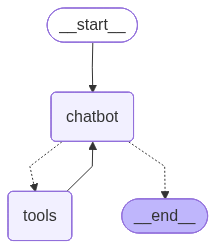

In [36]:
from IPython.display import Image, display

try:
    display(Image(graph.get_graph().draw_mermaid_png()))
except Exception as e:
    print(f"Could not render image ({e}). ASCII fallback:")
    print(graph.get_graph().draw_ascii())

## 7. Memory and session helpers

### 7.1 Send a message

In [37]:
def chat(user_id: str, thread_id: str, user_message: str) -> str:
    """Send a message in a given (user, thread) and return the assistant reply."""
    token = current_user_id.set(user_id)
    try:
        result = graph.invoke(
            {"messages": [HumanMessage(content=user_message)]},
            config={"configurable": {"thread_id": thread_id}},
        )
    finally:
        current_user_id.reset(token)
    return result["messages"][-1].content

In [38]:
def chat_verbose(user_id: str, thread_id: str, user_message: str) -> str:
    """Send a message and print intermediate tool calls before returning the final reply."""
    token = current_user_id.set(user_id)
    try:
        # Determine how many messages there were before
        state_before = graph.get_state(config={"configurable": {"thread_id": thread_id}})
        n_before = len(state_before.values.get("messages", [])) if state_before.values else 0

        result = graph.invoke(
            {"messages": [HumanMessage(content=user_message)]},
            config={"configurable": {"thread_id": thread_id}},
        )
    finally:
        current_user_id.reset(token)

    # Show only new messages
    new_messages = result["messages"][n_before:]
    for msg in new_messages:
        if hasattr(msg, "tool_calls") and msg.tool_calls:
            for tc in msg.tool_calls:
                print(f"Tool: {tc['name']} | args: {tc['args']}")
        elif hasattr(msg, "name") and msg.name:
            print(f"Result of {msg.name}: {str(msg.content)[:120]}...")

    return result["messages"][-1].content

### 7.2 Conversation registry


In [39]:
_threads_per_user: dict[str, list[str]] = {}

def new_thread(user_id: str) -> str:
    """Create a new conversation id for the user and register it."""
    tid = f"{user_id}-{uuid.uuid4().hex[:8]}"
    _threads_per_user.setdefault(user_id, []).append(tid)
    return tid

def list_threads(user_id: str) -> list[str]:
    """Return all known thread ids for a user (newest last)."""
    return list(_threads_per_user.get(user_id, []))

### 7.3 Inspect a conversation


In [40]:
def print_thread(thread_id: str) -> None:
    """Print every message currently stored under a thread_id."""
    snap = graph.get_state(config={"configurable": {"thread_id": thread_id}})
    if not snap or not snap.values.get("messages"):
        print(f"(thread {thread_id} is empty)")
        return
    for m in snap.values["messages"]:
        role = type(m).__name__.replace("Message", "")
        content = (m.content or "").replace("\n", " ")[:200]
        print(f"  [{role}] {content}")

### 8. Demo

### 8.1 Dataset Q&A - semantic + structured

In [41]:
alice_t1 = new_thread("alice")
print(chat_verbose("alice", alice_t1, "Give me 3 quick vegetarian pasta dishes, under 30 minutes."))

Tool: filter_recipes | args: {'max_minutes': 30, 'must_have_tag': 'vegetarian', 'limit': 3}
Tool: search_recipes | args: {'query': 'quick vegetarian pasta'}
Result of filter_recipes: - cottage cheese walnut dip (10 min, 9 ingredients)
- super easy lo mein (5 min, 7 ingredients)
- oatmeal white chocolat...
Result of search_recipes: - mediterranean   basil pasta (35.0 min) — ingredients: red peppers, red onions, red chili peppers, garlic cloves, super...
Here are three quick vegetarian pasta dishes that can be made in under 30 minutes:

1. **Easy Vegan Creamy Spaghetti** (25 minutes)
   - Ingredients: Spaghetti, marinara sauce, firm silken tofu, soymilk, nutritional yeast, red wine vinegar, salt, and pepper.

2. **Creamy Pasta with Mushrooms, Spinach, and Peas** (20 minutes)
   - Ingredients: Olive oil, margarine, onion, garlic cloves, mushrooms, flour, chicken stock, half-and-half.

3. **Jen's Southwestern Baked Spaghetti** (20 minutes)
   - Ingredients: Spaghetti, black beans, corn, re

### 8.2 Papers Q&A

In [42]:
print(chat_verbose("alice", alice_t1, "Summarize what multi-head attention is, citing the paper."))

Tool: search_papers | args: {'query': 'multi-head attention'}
Result of search_papers: - Source: Attention is all you need, page 3, chunk 2.0. Snippet: 3.2 Attention An attention function can be described as...
Multi-head attention is a mechanism that allows the model to jointly attend to information from different representation subspaces at different positions. It consists of several attention layers running in parallel, enabling the model to capture various aspects of the input data. Each attention head processes the input independently, and their outputs are concatenated and projected to form the final values. This approach helps in overcoming the limitations of a single attention head, which may average out important information.

For more details, see "Attention is All You Need," page 5.


### 8.3 Small talk (no tools)

In [43]:
print(chat_verbose("alice", alice_t1, "Hi, how are you today?"))

I'm just a program, but I'm here and ready to help you! How can I assist you today?


### 8.4 Save a long-term memory

In [44]:
print(chat_verbose("alice", alice_t1, "By the way, please remember I'm lactose intolerant and I love spicy food."))

Tool: save_memory | args: {'text': 'User is lactose intolerant.'}
Tool: save_memory | args: {'text': 'User loves spicy food.'}
Result of save_memory: Memory saved for user 'alice'....
Result of save_memory: Memory saved for user 'alice'....
I've noted that you're lactose intolerant and that you love spicy food. If there's anything else you'd like me to remember or if you need assistance, just let me know!


### 8.5 New conversation, same user — memory persists

In [45]:
alice_t2 = new_thread("alice")
print(chat_verbose("alice", alice_t2, "Suggest a dinner recipe I would enjoy."))

Tool: recall_memory | args: {}
Result of recall_memory: - User is lactose intolerant.
- User loves spicy food....
Tool: filter_recipes | args: {'must_have_tag': 'dinner', 'must_have_ingredient': 'spicy', 'max_minutes': 60}
Result of filter_recipes: No recipes match those filters....
Tool: search_recipes | args: {'query': 'spicy dinner', 'top_k': 5}
Result of search_recipes: - spicy steak casserole (225.0 min) — ingredients: stewing beef, flour, brown sugar, curry powder, ground ginger, worces...
Here are some spicy dinner recipes you might enjoy:

1. **Spicy Sweet Honey Chili** (50 min)
   - Ingredients: Ground beef, sweet onion, garlic clove, green bell pepper, jalapeno peppers, chili beans, diced tomatoes, chili powder.

2. **Sweet Spicy Asian Pork** (13 min)
   - Ingredients: Vegetable oil, cooked pork, yellow onion, red peppers, celery, sliced mushrooms, garlic cloves, brown sugar.

3. **Spicy Cuban Chicken** (60 min)
   - Ingredients: Fat-free Italian salad dressing, garlic cloves

### 8.6 Different user — no leakage from Alice's memory

In [46]:
bob_t1 = new_thread("bob")
print(chat_verbose("bob", bob_t1, "What do you remember about me?"))

Tool: recall_memory | args: {}
Result of recall_memory: No relevant memories found....
I don't have any information about you yet. If you'd like to share some details, I can remember them for future conversations!


### 8.7 Refusal when the agent does not know

In [47]:
print(chat_verbose("bob", bob_t1, "Who won the 2030 FIFA World Cup?"))

I don't have enough information to answer that.


### 8.8 Resume a paused conversation

In [48]:
print("Threads for alice:", list_threads("alice"))
print("\nResuming Alice's first thread:")
print(chat_verbose("alice", alice_t1, "What did I ask you first in this conversation?"))
print("\nFull message log of alice_t1:")
print_thread(alice_t1)

Threads for alice: ['alice-112a4ae5', 'alice-0ec55278']

Resuming Alice's first thread:
You asked for three quick vegetarian pasta dishes that can be made in under 30 minutes.

Full message log of alice_t1:
  [Human] Give me 3 quick vegetarian pasta dishes, under 30 minutes.
  [AI] 
  [Tool] - cottage cheese walnut dip (10 min, 9 ingredients) - super easy lo mein (5 min, 7 ingredients) - oatmeal white chocolate chip cookies (17 min, 11 ingredients)
  [Tool] - mediterranean   basil pasta (35.0 min) — ingredients: red peppers, red onions, red chili peppers, garlic cloves, superfine sugar, salt and pepper, olive oil, tomatoes - beef  and pasta with mushroom
  [AI] Here are three quick vegetarian pasta dishes that can be made in under 30 minutes:  1. **Easy Vegan Creamy Spaghetti** (25 minutes)    - Ingredients: Spaghetti, marinara sauce, firm silken tofu, soymi
  [Human] Summarize what multi-head attention is, citing the paper.
  [AI] 
  [Tool] - Source: Attention is all you need, page 3,

### 8.9 Update an outdated memory (preference changes over time)

In [49]:
# Alice states a stable preference in one conversation...
alice_t3 = new_thread("alice")
print(chat_verbose("alice", alice_t3, "Please remember that I am vegetarian."))

# ...and later, in a brand-new conversation, she changes it. The agent should
# recall the old fact and REPLACE it via update_memory, not keep both.
print("\n--- new conversation ---")
alice_t4 = new_thread("alice")
print(chat_verbose("alice", alice_t4, "Actually I'm not vegetarian anymore, I started eating meat."))

# Only the updated fact should remain.
print("\n--- check ---")
print(chat_verbose("alice", alice_t4, "What do you remember about my diet?"))

Tool: save_memory | args: {'text': 'User is vegetarian.'}
Result of save_memory: Memory saved for user 'alice'....
I've noted that you are vegetarian. If there's anything else you'd like me to remember or if you have any questions, feel free to ask!

--- new conversation ---
Tool: recall_memory | args: {'query': 'user is vegetarian'}
Result of recall_memory: - User is vegetarian.
- User loves spicy food.
- User is lactose intolerant....
Tool: update_memory | args: {'old_query': 'user is vegetarian', 'new_text': 'User is no longer vegetarian and eats meat.'}
Result of update_memory: Replaced memory 'User is vegetarian.' with 'User is no longer vegetarian and eats meat.' for user 'alice'....
I've updated your preference: you're no longer vegetarian and have started eating meat. If there's anything else you'd like to share or change, just let me know!

--- check ---
Tool: recall_memory | args: {'query': 'user dietary restrictions, allergies, food preferences, name and profile'}
Result of 

## 9. Gradio UI

In [50]:
import gradio as gr

def gradio_respond(message, chat_history, user_id, thread_id):
    """Glue between the Gradio chat widget and our `chat` function."""
    user_id = (user_id or "anon").strip() or "anon"
    if not thread_id.strip():
        thread_id = new_thread(user_id)
    reply = chat(user_id, thread_id, message)
    chat_history = (chat_history or []) + [
        {"role": "user", "content": message},
        {"role": "assistant", "content": reply},
    ]
    return "", chat_history, thread_id

with gr.Blocks(title="Agentic RAG — Recipes + Papers") as demo:
    gr.Markdown("# Agentic RAG — Recipes + Papers")
    gr.Markdown("Set a `User ID` to scope long-term memory. Leave `Thread ID` empty to start a new conversation.")
    with gr.Row():
        user_box   = gr.Textbox(label="User ID",   value="alice", scale=1)
        thread_box = gr.Textbox(label="Thread ID", value="",       scale=2)
    chat_widget = gr.Chatbot(height=420, type="messages", allow_tags=False)
    msg = gr.Textbox(label="Your message", placeholder="Ask about recipes, papers, or anything…")
    clear = gr.Button("New conversation")

    msg.submit(gradio_respond, [msg, chat_widget, user_box, thread_box], [msg, chat_widget, thread_box])
    clear.click(lambda: ([], ""), None, [chat_widget, thread_box])

demo.launch(share=True)

/tmp/ipykernel_10060/332799074.py:21: DeprecationWarning: The default value of 'allow_tags' in gr.Chatbot will be changed from False to True in Gradio 6.0. You will need to explicitly set allow_tags=False if you want to disable tags in your chatbot.
  chat_widget = gr.Chatbot(height=420, type="messages", allow_tags=False)


Colab notebook detected. To show errors in colab notebook, set debug=True in launch()
* Running on public URL: https://8c78ccb4c8686601ed.gradio.live

This share link expires in 1 week. For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)


## 10. Evaluation and requirement checks

This section gives a repeatable way to show the system covers the assignment requirements:

- dataset questions;
- paper/document questions;
- long-term memory;
- user isolation;
- short-term conversation context;
- refusal when there is not enough information.

Run these cells after the graph and tools have been built.

In [51]:
EVAL_CASES = [
    {
        "name": "Save long-term memory",
        "user_id": "eval_alice",
        "message": "Remember that I am lactose intolerant and I like spicy food.",
        "checks": ["calls save_memory once or reports duplicate", "stores stable user preference"],
    },
    {
        "name": "Recall memory and apply dietary restriction",
        "user_id": "eval_alice",
        "message": "Suggest a spicy dinner under 60 minutes based on what you remember about me.",
        "checks": ["calls recall_memory", "uses lactose memory", "uses recipe tools"],
    },
    {
        "name": "Inspect user memory",
        "user_id": "eval_alice",
        "message": "What do you remember about me?",
        "checks": ["calls recall_memory", "shows only Alice memories"],
    },
    {
        "name": "User isolation",
        "user_id": "eval_bob",
        "message": "What do you remember about me?",
        "checks": ["does not reveal Alice memories"],
    },
    {
        "name": "Save a preference to later update",
        "user_id": "eval_carol",
        "message": "Remember that I am vegetarian.",
        "checks": ["calls save_memory once", "stores vegetarian preference"],
    },
    {
        "name": "Update an outdated preference",
        "user_id": "eval_carol",
        "new_thread": True,
        "message": "I am not vegetarian anymore, I started eating meat.",
        "checks": ["calls recall_memory then update_memory", "old vegetarian memory is replaced", "no conflicting memory kept"],
    },
    {
        "name": "Forget a memory on request",
        "user_id": "eval_carol",
        "new_thread": True,
        "message": "Please forget everything you know about my diet.",
        "checks": ["calls forget_memory", "deletes the diet memory"],
    },
    {
        "name": "Recipe query with hard constraints",
        "user_id": "eval_bob",
        "message": "Give me 2 vegetarian pasta ideas under 30 minutes.",
        "checks": ["uses recipe tools", "respects time/tag/ingredient constraints", "does not invent recipes"],
    },
    {
        "name": "Paper-grounded answer",
        "user_id": "eval_bob",
        "message": "Explain multi-head attention and cite the paper page.",
        "checks": ["uses search_papers", "cites paper/page", "does not answer from memory only"],
    },
    {
        "name": "Unknown future event",
        "user_id": "eval_bob",
        "message": "Who won the 2030 FIFA World Cup?",
        "checks": ["admits lack of information", "does not invent"],
    },
]

pd.DataFrame(EVAL_CASES)

,name,user_id,message,checks,new_thread
0,Save long-term memory,eval_alice,Remember that I am lactose intolerant and I li...,"[calls save_memory once or reports duplicate, ...",NaN
1,Recall memory and apply dietary restriction,eval_alice,Suggest a spicy dinner under 60 minutes based ...,"[calls recall_memory, uses lactose memory, use...",NaN
2,Inspect user memory,eval_alice,What do you remember about me?,"[calls recall_memory, shows only Alice memories]",NaN
3,User isolation,eval_bob,What do you remember about me?,[does not reveal Alice memories],NaN
4,Save a preference to later update,eval_carol,Remember that I am vegetarian.,"[calls save_memory once, stores vegetarian pre...",NaN
5,Update an outdated preference,eval_carol,"I am not vegetarian anymore, I started eating ...","[calls recall_memory then update_memory, old v...",True
6,Forget a memory on request,eval_carol,Please forget everything you know about my diet.,"[calls forget_memory, deletes the diet memory]",True
7,Recipe query with hard constraints,eval_bob,Give me 2 vegetarian pasta ideas under 30 minu...,"[uses recipe tools, respects time/tag/ingredie...",NaN
8,Paper-grounded answer,eval_bob,Explain multi-head attention and cite the pape...,"[uses search_papers, cites paper/page, does no...",NaN
9,Unknown future event,eval_bob,Who won the 2030 FIFA World Cup?,"[admits lack of information, does not invent]",NaN


In [52]:
def run_eval_cases(cases: list[dict]) -> None:
    """Run the evaluation cases and print tool traces plus final answers.

    This is not an automatic grader. It is a demo/evaluation harness: each case
    prints the expected checks so we can manually verify behavior during the
    defense or while iterating on the notebook.
    """
    threads_by_user = {}
    for case in cases:
        user_id = case["user_id"]
        thread_id = threads_by_user.get(user_id)
        if thread_id is None or case.get("new_thread") or case["name"] == "Recall memory and apply dietary restriction":
            thread_id = new_thread(user_id)
            threads_by_user[user_id] = thread_id

        print("=" * 90)
        print(f"CASE: {case['name']}")
        print(f"USER: {user_id} | THREAD: {thread_id}")
        print(f"MESSAGE: {case['message']}")
        print(f"EXPECTED CHECKS: {', '.join(case['checks'])}")
        print("-" * 90)
        answer = chat_verbose(user_id, thread_id, case["message"])
        print("\nFINAL ANSWER:")
        print(answer)


# Set to False if you want to avoid extra OpenAI calls while editing.
RUN_FULL_EVAL = True
if RUN_FULL_EVAL:
    run_eval_cases(EVAL_CASES)

CASE: Save long-term memory
USER: eval_alice | THREAD: eval_alice-76e94482
MESSAGE: Remember that I am lactose intolerant and I like spicy food.
EXPECTED CHECKS: calls save_memory once or reports duplicate, stores stable user preference
------------------------------------------------------------------------------------------
Tool: save_memory | args: {'text': 'User is lactose intolerant and likes spicy food.'}
Result of save_memory: Memory saved for user 'eval_alice'....

FINAL ANSWER:
I've noted that you are lactose intolerant and like spicy food! If there's anything else you'd like me to remember or if you have any questions, just let me know.
CASE: Recall memory and apply dietary restriction
USER: eval_alice | THREAD: eval_alice-3b2c5a10
MESSAGE: Suggest a spicy dinner under 60 minutes based on what you remember about me.
EXPECTED CHECKS: calls recall_memory, uses lactose memory, uses recipe tools
-------------------------------------------------------------------------------------